# Основы объектно-ориентированого программирования

Сегодня мы создаим свой первый класс Class CityFeaturing. Но для начала вспомним прошлые занятия и напишем 6 функций:

1. Получает название города и записывает его в переменную
2. Получает площадь города и население и записывает в переменную
3. Расчитывает и возвращает плотность города
4. Считает обеспеченность школами на вход - количество школ в городе
5. Определение статуса "Зеленый город" - считаем процент зеленый город и присваимвам True, если процент больше 50. 
6. Метод с выводом отчета в виде словаря. 

In [1]:
# 1. Получает название города и записывает его в переменную
def get_name(name: str) -> str:
    return name

In [2]:
# 2. Получает площадь города и население и записывает в переменную
def get_features(area: float, population: int) -> float:
    return area, population

In [3]:
# 3. Расчитывает и возвращает плотность города
def dencity_calc(area: float, population: int) -> float:
    dencity =  population / area
    return dencity

In [4]:
# 4. Считает обеспеченность школами на вход - количество школ в городе
def provision_calc(schools: int, population: int) -> float:
    CHILD_INDEAX = 0.3 # дети составляюттреть населения, примерно
    SCHOOL_INDEX = 1000 # обеспеченность обычно счиатеся на 1000 населения
    provision = (SCHOOL_INDEX  * schools) / (CHILD_INDEAX * population)
    return provision

In [5]:
# 5. Определение статуса "Зеленый город" - считаем процент зеленый город и присваимвам True, если процент больше 50. 
def is_green_city(green_zone_area: float, area: float) -> bool:
    is_green = True if green_zone_area / area > 0.5 else False
    return is_green

In [6]:
# 6. Метод с выводом отчета в виде словаря.
def print_report(name, area, population, dencity, provision, is_green):
    report = {}
    report['Название города'] = name
    report['Площадь города'] = area
    report['Население города'] = population
    report['Плотность население'] = dencity
    report['Обеспеченность школами'] = provision
    report['Зеленый город'] = is_green
    return report

In [7]:
city = get_name('Псков')
city

'Псков'

In [8]:
areas, pop = get_features(96, 200000)
areas, pop

(96, 200000)

In [9]:
dens = dencity_calc(96, 200000)
dens

2083.3333333333335

In [10]:
prov = provision_calc(30, pop)
prov

0.5

In [11]:
is_green = is_green_city(60, areas)
is_green

True

In [12]:
print_report(name=city, area=areas, population=pop, dencity=dens, provision=prov, is_green=is_green)

{'Название города': 'Псков',
 'Площадь города': 96,
 'Население города': 200000,
 'Плотность население': 2083.3333333333335,
 'Обеспеченность школами': 0.5,
 'Зеленый город': True}

#### Задача:
В отдельном файлике, который назовем *cityclass.py*, создадим класс *CityFeaturing*.  

Каждая функция станет методом этого класса. 

In [13]:
from cityclass import CityFeaturing

pskov = CityFeaturing() # создаем экземпляр (объект класса)

# поочередно вызываем методы объекта и записываем результат в переменные
city = pskov.get_name(name='Псков') 
area, population = pskov.get_features(_area=200, _population=450000)
density = pskov.density_calc(_area=area, _population=population)
provision = pskov.provision_calc(_schools=52, _population=population)
is_green = pskov.is_green_city(_green_zone_area=40, _area=area)

# передаем переменные в качестве атрибутов вмметод print_report()
report_dict = pskov.print_report(name=city, _area=area, _population=population,
                                _density=density, _provision=provision, _is_green=is_green)

In [14]:
# возвращаем итоговый словарь
report_dict

{'Название города': 'Псков',
 'Площадь города': 200,
 'Население города': 450000,
 'Плотность население': 2250.0,
 'Обеспеченность школами': 0.3851851851851852,
 'Зеленый город': False}

##### Зачем нужен *self*?

*self* — это специальный параметр в методах класса Python, который ссылается на конкретный экземпляр (объект) этого класса.

Когда вы создаёте объект класса и вызываете его метод, Python автоматически передаёт в метод ссылку на этот объект — именно её и принимает параметр self. Это позволяет:

* обращаться к атрибутам (свойствам) текущего объекта;

* вызывать другие методы этого же объекта;

* изменять состояние объекта внутри методов.

In [15]:
class Dog:
    def __init__(self, name):
        self.name = name  # сохраняем имя в атрибут объекта


    def bark(self):
        print(f"{self.name} говорит: Гав!")  # используем атрибут через self

# Создаём два объекта
dog1 = Dog("Шарик")
dog2 = Dog("Бобик")


# Вызываем метод
dog1.bark()  # Шарик говорит: Гав!
dog2.bark()  # Бобик говорит: Гав!

Шарик говорит: Гав!
Бобик говорит: Гав!


Что происходит при вызове *dog1.bark()*:

* Python автоматически передаёт объект *dog1* в метод как первый аргумент (*self*).

* Внутри метода *self* становится ссылкой на *dog1*.

* *self.name* обращается к атрибуту name именно объекта *dog1*.

**Ключевые моменты**

* Имя self — соглашение, а не ключевое слово  
Хотя можно использовать любое имя (например, this), self — общепринятый стандарт. Код с self легче читать и понимать.

* Обязательно в методах экземпляра  
Все методы, работающие с данными объекта, должны принимать self как первый параметр.

* Не передаётся явно при вызове  
Вы пишете obj.method(), а Python сам подставляет obj как self.

* Нужен для доступа к атрибутам  
Без self нельзя обратиться к атрибутам объекта (self.attribute).

* Обеспечивает изоляцию объектов  
Каждый объект имеет свои атрибуты, и self гарантирует, что метод работает именно с «его» данными.

In [16]:
# Что будет, если забыть self
class Example:
    def broken_method(self, value):
        # Забыли self перед атрибутом!
        my_value = value  # Это локальная переменная, не атрибут!

obj = Example()
obj.broken_method(10)
print(obj.my_value)  # Ошибка! Атрибута нет

AttributeError: 'Example' object has no attribute 'my_value'

Для обычных методов экземпляра *self* нужен всегда. Без него:

* Python не поймёт, к какому объекту обращаться;

* возникнет ошибка при вызове через экземпляр.

#### Метод *__init__*

Это специальный метод в Python (конструктор), который автоматически вызывается при создании нового экземпляра класса. Его главная задача — инициализировать атрибуты объекта (задать им начальные значения).

**Зачем он нужен: ключевые функции**

1. Задаёт начальное состояние объекта  
При создании объекта (Dog("Шарик")) вы сразу указываете, какими данными он будет обладать. Без *__init__* пришлось бы вручную присваивать атрибуты после создания.

2. Обеспечивает обязательные параметры  
Если для работы класса нужны определённые данные (например, имя собаки), *__init__* гарантирует, что они будут переданы при создании объекта.

3. Автоматизирует настройку  
Все подготовительные действия (создание атрибутов, вычисления, проверки) выполняются автоматически при инициализации.

In [17]:
class CityFeaturing():
    def __init__(self, _name: str):
        self.name = _name

    def get_name(self) -> str:
        '''Получает название города и записывает его в переменную'''
        return self.name
    
cf = CityFeaturing('Псков')
print(cf.get_name())

Псков


#### Перепишем класс CityFeaturing
Переписываем в отдельном файле *improved_cityclass.py* 

In [18]:
# Запустим обновленный класс
from improved_cityclass import CityFeaturing

tver = CityFeaturing(_name='Тверь', _area=200, _population=450000, 
                   _schools=52, _treshold = 0.5, _green_zone_area=40) # создаем экземпляр (объект класса)

# поочередно вызываем методы объекта и записываем результат в переменные
city = tver.get_name() # по сути, этот метод здесь больше не нужен
area, population = tver.get_features() # по сути, этот метод здесь больше не нужен
density = tver.density_calc()
provision = tver.provision_calc()
is_green = tver.is_green_city()

# передаем переменные в качестве атрибутов в метод print_report()
report_dict = tver.print_report()
report_dict

{'Название города': 'Тверь',
 'Площадь города': 200,
 'Население города': 450000,
 'Плотность население': 2250.0,
 'Количество школ': 52,
 'Обеспеченность школами': 0.3851851851851852,
 'Зеленый город': False}

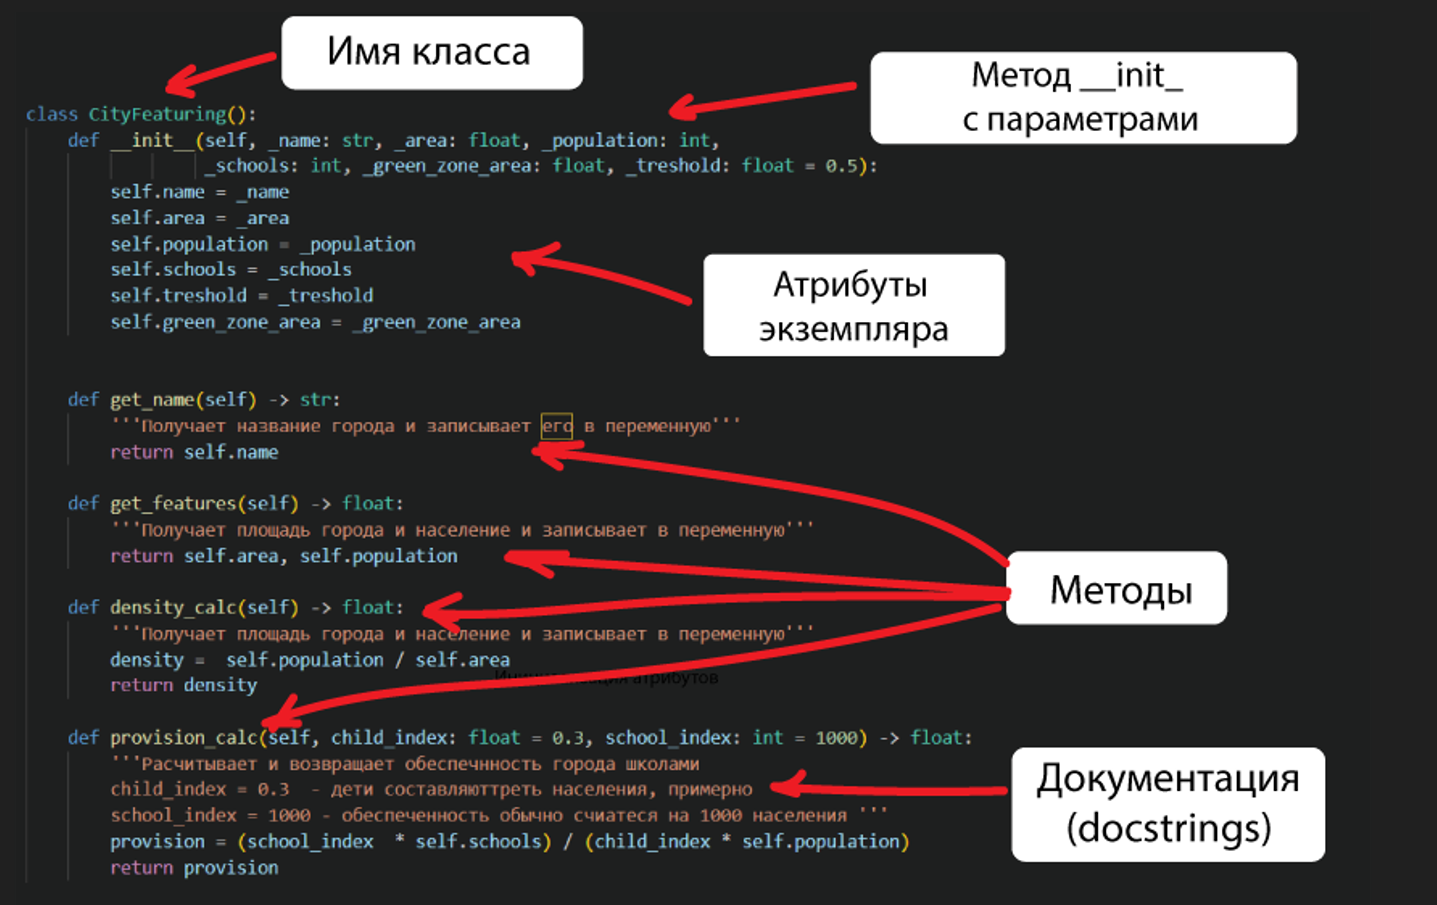

### Ключевые принципы ООП: инкапсуляция, наследование, полиморфизм и абстракция

#### 1. Инкапсуляция

Суть: сокрытие внутренней реализации объекта; доступ к данным через контролируемые методы.

**Инкапсуляция** (от лат. in capsule — в оболочке) — это заключение данных и функциональности в оболочку. В объектно-ориентированном программировании в роли оболочки выступают классы: они не только собирают переменные и методы в одном месте, но и защищают их от вмешательства извне (сокрытие).

Как проявляется в классе:

* Атрибуты (*name*, *area*, *population* и др.) хранятся внутри объекта и не доступны напрямую для изменения извне.

* Для получения данных предусмотрены методы‑геттеры (*get_name()*, *get_features()*), хотя в Python это не всегда необходимо.

* Логика расчётов (например, плотность населения в *dencity_calc()*) «спрятана» внутри методов — пользователь не видит формул.

Почему это важно:

* Защищает данные от некорректного изменения (например, нельзя случайно задать отрицательное население).

* Позволяет менять внутреннюю реализацию без влияния на пользователей класса.

#### 2. Наследование

Суть: создание нового класса на основе существующего с добавлением/изменением функционала.

**Наследование** — это концепция, согласно которой одни классы, называемые родительскими, могут лежать в основе других — дочерних. При этом, дочерние классы перенимают свойства и поведение своего родителя.

Как применить к нашему классу?

Можно создать подклассы для разных типов городов, унаследовав базовые атрибуты и методы:

In [ ]:
class ResortCity(CityFeaturing):
    def __init__(self, name: str, area: float, population: int, schools: int,
                 green_zone_area: float, annual_tourists: int, threshold: float = 0.4):
        # Передаём ВСЕ обязательные параметры родителю
        super().__init__(name, area, population, schools, threshold, green_zone_area)
        self.annual_tourists = annual_tourists

    def peak_load(self) -> float:
        total_people = self.population + self.annual_tourists
        return total_people / self.area

    def tourist_ratio(self) -> float:
        return self.annual_tourists / self.population
    

In [ ]:
# Создаём курортный город
sochi = ResortCity(
name="Сочи",
area=350.0,
population=500_000,
schools=50,
green_zone_area=150.0,
annual_tourists=7_000_000
)

# Используем методы родителя
print(f"Плотность населения: {sochi.density_calc():.1f} чел./км²")
print(f"Зелёный город: {sochi.is_green_city()}")

# Используем методы дочернего класса
print(f"Нагрузка в сезон: {sochi.peak_load():.1f} чел./км²")
print(f"Туристы к жителям: {sochi.tourist_ratio():.1f}x")

Плотность населения: 1428.6 чел./км²
Зелёный город: False
Нагрузка в сезон: 21428.6 чел./км²
Туристы к жителям: 14.0x


Почему это важно:

* Позволяет повторно использовать код.

* Упрощает добавление новых типов объектов.

* Поддерживает принцип «открыто для расширения, закрыто для изменения».

Что учесть:

* Используйте super() для вызова методов родительского класса.

* Переопределяйте только необходимые методы.

#### 3. Полиморфизм

Суть: один интерфейс — разные реализации. Объект может вести себя по‑разному в зависимости от контекста.

**Полиморфизм** (от др. греч. poly — много, morph — форма) — это возможность объектов разных классов использовать один и тот же интерфейс (то есть методы с одинаковым названием), но при этом реализовывать их по-разному.

Как можно реализовать в нашем классе?

Сейчас полиморфизм явно не используется, но его легко добавить. Например, метод *describe()* может работать по‑разному для разных типов городов:

In [19]:
# родительский класс — описывает общие свойства любого сервиса (больница, школа и т. п.).
class SomeServis:
    def __init__(self, name, adress, foundation, date = 2026):
        self.name = name
        self.adress = adress
        self.foundation = foundation
        self.date = date

    def info(self):
        print(f'The {self.name} was build {self.date - self.foundation} yers ago.')
    
    def location(self):
        print(f'The {self.name} is located on {self.adress}.')  


service = SomeServis(
    name='Hospital',
    adress = 'Bradley Cooper Street',
    foundation = 1910,
)

service.info()
service.location()
service.name


The Hospital was build 116 yers ago.
The Hospital is located on Bradley Cooper Street.


'Hospital'

In [24]:
# дочерний класс - наследует от SomeServis, но добавляет свою специфику (вместимость).
class SomeSchool(SomeServis):
    def __init__(self, name, adress, foundation, capacity, date = 2026):
        super().__init__(name, adress, foundation, date) # вызывает конструктор родителя, чтобы не дублировать код.
        self.capacity = capacity # новый атрибут, специфичный для школы.
    
    def capacity_info(self):
        self.location()
        print(f'There are {self.capacity} persons in the {self.name}.')

school = SomeSchool(
    name='13th school',
    adress = 'Bradly Cooper Street',
    foundation = 1910,
    capacity=850
)

school.capacity_info()

print('=' *50)
school.info()

print('=' *50)
print(school.name)
print(school.adress)

The 13th school is located on Bradly Cooper Street.
There are 850 persons in the 13th school.
The 13th school was build 116 yers ago.
13th school
Bradly Cooper Street


*capacity_info()* использует:

1. *self.location()* (метод родителя!);
2. *self.capacity* (свой собственный атрибут).

**Ключевой момент полиморфизма**

Методы *info()* и *location()* определены в родительском классе, но:
* их могут вызывать и родитель, и любой другой потомок;
* при вызове из потомка они используют данные именно этого потомка (благодаря self).

#### 4. Абстракция

Суть: скрытие сложных деталей, акцент на важном. Пользователь работает с упрощённым интерфейсом.

**Абстракция** — это процесс выделения существенных характеристик объекта, отличающих его от других объектов, и игнорирования несущественных деталей. В контексте ООП абстракция позволяет создать упрощенную модель сложной системы, фокусируясь на том, что объект делает, а не на том, как он это делает.

Как проявляется в нашем классе:
1. Пользователь создаёт объект CityFeaturing и вызывает методы (dencity_calc(), is_green_city()), не зная, как именно идут расчёты внутри.
2. Детали реализации (формулы, проверки) «спрятаны» в методах.
3. Внешний интерфейс класса минимален: только нужные методы, без избыточных данных.

Пример:
Метод is_green_city() абстрагирует сложную проверку:

In [ ]:
# Пользователь видит только True/False, не зная порога и формулы
def is_green_city(self) -> bool:
        '''Определение статуса "Зеленый город" - 
        считаем процент зеленый город и присваимвам True, 
        если процент больше порога. '''
        is_green = True if self.green_zone_area / self.area > self.treshold else False
        return is_green

tver.is_green_city()    

False

Почему это важно:
* Упрощает использование класса.
* Позволяет изменять внутреннюю логику без влияния на пользователей.